
## **<u>Final Project: Length of Stay (LOS) Prediction and managerial analysis of hospital data</u>**

#### *Programming for Management Studies (MGTHN0144)*

##### Team members: Muhammad Sheheryaar Ghayas (03801683), Vsevolods Mitrevics (03815799), Constantin Demuth (03818527), Stanislaw Pohl (03822985), Jannis Nickel (03813516)
------------------------------------------------------

### **(0) Preamble**

- For our final Project, we decided on the analysis of hospital data. The dataset used is taken from the list of allowed datasets for the final project and can be found under [this link.](https://www.kaggle.com/datasets/nehaprabhavalkar/av-healthcare-analytics-ii?resource=download)
- We decided on focussing on the following aspects for our project:
    1. **Which department produces the longest lengths of stay** and are thus the most costly for a hospital?
    2. **Length of Stay (short: LOS) prediction** via the usage a self-trained machine-learning model
- This notebook can be run independently, but needs to be within the folder where the dataset and the pre-trained ML model is included.
- [Further instructions??]
- This notebook is built in the following chronological order necessary to solve the given tasks:
    1. Imports, Data Loading and Cleaning, 
    2. Visualisations and Correlation,
    3. Training and Implementation of ML Model,
    4. Conclusion.

---------------------

### **(1) Imports, Data Loading, Cleaning and Preparation**

#### **(i) Necessary imports**
These imports are necessary to run the notebook. Please ensure they are installed beforehand, or run the corresponding install commands (e.g. pip install ...)

In [3]:
'''imports'''
import pandas as pd
import matplotlib as plt
import numpy as np
import torch
from torch import nn
from sklearn.model_selection import train_test_split
import os
import random
import csv
import itertools
import math
import statistics
from collections import defaultdict
from pathlib import Path
from typing import Any

#### **(ii) Importing the .csv-file, setting variables**
This snippet saves the given dataset as a variable. <br>
Further, necessary variables for the ML model and the rest of our code are defined here. <br>
***Important! If you need to change the import to another location, please adjust this here globally!***

In [4]:
FILE_PATH = "Topic3_healthcare_analytics_dataset.csv"
csv_file = Path("Topic3_healthcare_analytics_dataset.csv")
RANDOM_SEED = 23
DEVICE = "cuda" if torch.cuda.is_available() else "cpu" #if a gpu is available -> take it instead of CPU
TRAINING_BATCH_SIZE = 128
TEST_BATCH_SIZE = 256
stay_order = [
    "0-10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100",
    "More than 100 Days",
]

# Midpoints turn interval labels into approximate numbers.
# Example: "41-50" becomes 45.5 days.
stay_midpoints = {
    "0-10": 5.0,
    "11-20": 15.5,
    "21-30": 25.5,
    "31-40": 35.5,
    "41-50": 45.5,
    "51-60": 55.5,
    "61-70": 65.5,
    "71-80": 75.5,
    "81-90": 85.5,
    "91-100": 95.5,
    "More than 100 Days": 110.0,
}

age_midpoints = {
    "0-10": 5.0,
    "11-20": 15.5,
    "21-30": 25.5,
    "31-40": 35.5,
    "41-50": 45.5,
    "51-60": 55.5,
    "61-70": 65.5,
    "71-80": 75.5,
    "81-90": 85.5,
    "91-100": 95.5,
}

# These are the numeric features we compare with length of stay.
correlation_features = [
    "age_midpoint",
    "Available Extra Rooms in Hospital",
    "Visitors with Patient",
    "Admission_Deposit",
    "Bed Grade",
]

# Shorter labels make the charts easier to read.
feature_labels = {
    "age_midpoint": "Age midpoint",
    "Available Extra Rooms in Hospital": "Available extra rooms",
    "Visitors with Patient": "Visitors with patient",
    "Admission_Deposit": "Admission deposit",
    "Bed Grade": "Bed grade",
}

#### **(iii) Data Cleaning**
Here, the given dataset is cleaned, using the following ruleset: <br>
(a) rows that miss at least one value are dropped <br>
(b) overwriting the .csv-file with the new file <br>
(c) changing the case_id s.t. it is continuous again after deleting rows <br>

In [5]:

def clean_csv(file_path: str) -> None:
	"""Read CSV at file_path, drop any rows with at least one missing value,
	and overwrite the same CSV file if any rows were removed.
	"""
	try:
		df = pd.read_csv(file_path)
	except FileNotFoundError:
		print(f"File not found: {file_path}")
		return

	original_rows = len(df)
	df_clean = df.dropna(how="any")
	cleaned_rows = len(df_clean)
	removed = original_rows - cleaned_rows

	if removed > 0:
		df_clean.to_csv(file_path, index=False)
		print(f"Removed {removed} rows with missing data")
	else:
		print(f"No rows removed")
clean_csv(FILE_PATH) # run the function

No rows removed


In [6]:

def reset_case_id(file_path: str) -> None:
	"""Read CSV at file_path, reset case_id to be continuous (1, 2, 3, ...),
	and overwrite the file.
	"""
	try:
		df = pd.read_csv(file_path)
	except FileNotFoundError:
		print(f"File not found: {file_path}")
		return

	old_count = len(df)
	df["case_id"] = range(1, len(df) + 1)
	df.to_csv(file_path, index=False)
	print(f"Reset case_id (1 to {len(df)})")
reset_case_id(FILE_PATH) # run function

Reset case_id (1 to 313793)


#### **(iv) Loading and Preparation for the following analysis**

The dataset stores `Stay` as categories such as `0-10` and `41-50`. For averages and correlations, each stay category is converted into an approximate midpoint in days.

In [7]:
def to_number(value: Any) -> float | None:
    """Change one CSV value into a number. If this is not possible, return None."""
    text = "" if value is None else str(value).strip()
    if text == "":
        return None
    try:
        number = float(text)
    except ValueError:
        return None
    if math.isnan(number):
        return None
    return number

print(to_number("42"))

42.0


In [8]:
def load_prepared_rows(csv_path: Path = csv_file) -> list[dict[str, Any]]:
    """Load the CSV and add the extra numeric columns that are needed for the analysis."""
    with csv_path.open(newline="", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        rows = []
        for row in reader:
            clean_row = {key: ("" if value is None else str(value).strip()) for key, value in row.items()}

            # Add numeric versions of Stay and Age so we can calculate averages and correlations.
            clean_row["stay_days"] = stay_midpoints.get(clean_row["Stay"])
            clean_row["age_midpoint"] = age_midpoints.get(clean_row["Age"])

            # Convert the other selected correlation features from text to numbers.
            for column in [
                "Available Extra Rooms in Hospital",
                "Visitors with Patient",
                "Admission_Deposit",
                "Bed Grade",
            ]:
                clean_row[column] = to_number(clean_row[column])

            rows.append(clean_row)
    return rows

rows = load_prepared_rows(csv_file)
print(f"Rows loaded: {len(rows):,}")

Rows loaded: 313,793


### **(2) Which department produces the longest LOS in the long-run and is thus the most costly?**

#### **(i) Abstract and Managerial Introduction**


1. ***Clinical and Financial Context***<br>
Financing in German healthcare is based on the G-DRG system, which simply assigns a financing time window for different types of diagnoses. When hospitalizations exceed the threshold ("obere Grenzverweildauer"), the hospital receives only a flat per diem payment.<br>
This system becomes problematic when considering the fact that long hospital stays are rarely normal and are usually tied to extreme severity cases with immense complications. This correlation creates a high threat of amassing costs for the hospital, as these patients often require far more specialized care, costly procedures, and an overall greater share of the hospital's resources.<br> Basically, the longer these types of patients stay, the higher the financial burden is for the hospital.<br>
An aim of the hospital administration should be to ensure that patients are treated with such efficiency that they can leave the ward within the time window allocated by the DRG, while also ensuring the stay is long enough for them to be fully cured.

2. ***Managerial Insight***<br>
Hospital leadership cannot, of course, forcefully remove patients who are about to exceed the regulatory threshold, and in many cases, they must simply absorb the losses connected with the prolonged stays of severely ill patients.<br>
The actionable steps they can pursue, however, involve identifying the specific departments or wards in the hospital that deal with prolonged stays most often. <br> This observation can be a key point for managerial staff when allocating resources to improve a department's efficiency in helping patients finish their hospitalization on time and in good health. Investments in better and newer equipment, increasing human resources, or hiring top specialists can all be decided upon after finding out which department is struggling the most.

3. ***Goal***<br>
By analyzing the provided data, we aim to find which department, on average, struggles with long Lengths of Stay (LOS) the most and would therefore be the best candidate for a capital investment.

#### **(ii) Solution via aggregation and statistical analysis of the dataset**

##### **1. Overview of our solution (UML diagram)**



In the following UML diagram, an overview is given over the statistical analysis of the dataset in order to solve the given question:

![UML](./graphics/vertical.jpg)

##### **2. Find the department with the longest average LOS**

This step answers the main question directly by ranking departments by average stay length.

In [9]:
def mean(values: list[float]) -> float:
    """Calculate the average of a list of numbers."""
    return sum(values) / len(values)

print(mean([10.0, 20.0, 30.0]))

20.0


In [10]:
def get_department_los_summary(rows: list[dict[str, Any]]) -> list[dict[str, Any]]:
    """Group patients by department and calculate the LOS summary for each department."""
    grouped_stays = defaultdict(list)
    for row in rows:
        if row["stay_days"] is not None:
            grouped_stays[row["Department"]].append(row["stay_days"])

    summary = []
    for department, stay_values in grouped_stays.items():
        summary.append(
            {
                "department": department,
                "patients": len(stay_values),
                "mean_stay_days": mean(stay_values),
                "median_stay_days": statistics.median(stay_values),
            }
        )

    # The first row after sorting is the department with the longest average LOS.
    return sorted(summary, key=lambda row: row["mean_stay_days"], reverse=True)

department_los = get_department_los_summary(rows)
longest_los_department = department_los[0]["department"]
longest_los_days = department_los[0]["mean_stay_days"]

for row in department_los:
    print(
        f"{row['department']:20} "
        f"patients={row['patients']:7,} "
        f"mean={row['mean_stay_days']:5.1f} days "
        f"median={row['median_stay_days']:5.1f} days"
    )

print(f"\nLongest average LOS: {longest_los_department} ({longest_los_days:.1f} days)")

surgery              patients=  1,143 mean= 38.1 days median= 35.5 days
radiotherapy         patients= 28,153 mean= 33.7 days median= 25.5 days
gynecology           patients=245,850 mean= 32.6 days median= 25.5 days
TB & Chest disease   patients=  9,460 mean= 31.4 days median= 25.5 days
anesthesia           patients= 29,187 mean= 30.6 days median= 25.5 days

Longest average LOS: surgery (38.1 days)


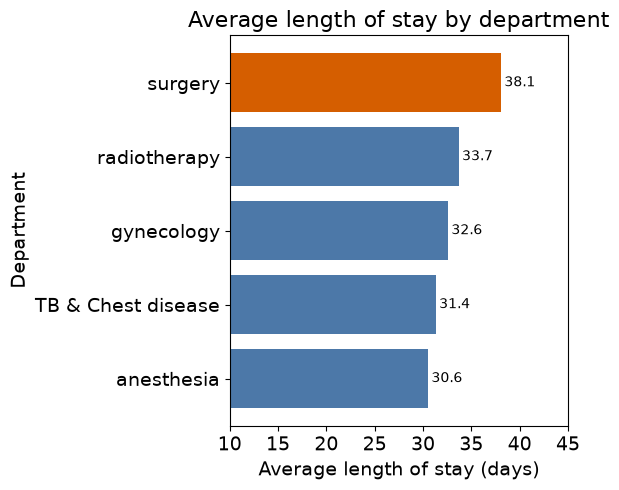

In [40]:
def show_department_los_chart(department_los: list[dict[str, Any]]) -> None:
    """Draw a bar chart that compares the average LOS of all departments."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    plot_rows = sorted(department_los, key=lambda row: row["mean_stay_days"])
    departments = [row["department"] for row in plot_rows]
    mean_stays = [row["mean_stay_days"] for row in plot_rows]
    colors = ["#d55e00" if department == longest_los_department else "#4c78a8" for department in departments]

    _, axis = plt.subplots(figsize=(6, 5))
    axis.barh(departments, mean_stays, color=colors)
    axis.set_title("Average length of stay by department", fontsize=16)
    axis.set_xlabel("Average length of stay (days)", fontsize=14)
    axis.set_ylabel("Department", fontsize=14)
    axis.set_xlim(left=20)
    axis.set_xticks(np.arange(10, max(mean_stays) + 10, 5))
    axis.tick_params(axis="both", labelsize=14)
    #adapted graph to be formatted suitable for the report (since page limit is 5)

    # Put the exact average LOS next to each bar so the chart is easy to present.
    for department, value in zip(departments, mean_stays):
        axis.text(value + 0.3, department, f"{value:.1f}", va="center")

    plt.tight_layout()
    plt.show()

show_department_los_chart(department_los)

##### **3. Direct correlations inside the longest-stay department**

Now we only look at the department with the longest average LOS. Direct correlations show which individual numeric variables move together with LOS inside that department.

In [41]:
def pearson_correlation(first_values: list[float], second_values: list[float]) -> float | None:
    """Measure how strongly two numeric lists move together. The result is between -1 and 1."""
    pairs = [(x, y) for x, y in zip(first_values, second_values) if x is not None and y is not None]
    if len(pairs) < 2:
        return None

    x_values = [pair[0] for pair in pairs]
    y_values = [pair[1] for pair in pairs]
    x_mean = mean(x_values)
    y_mean = mean(y_values)

    numerator = sum((x - x_mean) * (y - y_mean) for x, y in pairs)
    x_denominator = math.sqrt(sum((x - x_mean) ** 2 for x in x_values))
    y_denominator = math.sqrt(sum((y - y_mean) ** 2 for y in y_values))

    if x_denominator == 0 or y_denominator == 0:
        return None
    return numerator / (x_denominator * y_denominator)

print(pearson_correlation([1.0, 2.0, 3.0], [1.0, 2.0, 4.0]))

0.9819805060619655


In [42]:
def get_direct_correlations(rows: list[dict[str, Any]], department: str) -> list[dict[str, Any]]:
    """Calculate how each single feature is related to LOS inside one department."""
    department_rows = [row for row in rows if row["Department"] == department]
    stay_values = [row["stay_days"] for row in department_rows]

    results = []
    for feature in correlation_features:
        feature_values = [row[feature] for row in department_rows]
        correlation = pearson_correlation(feature_values, stay_values)
        results.append(
            {
                "feature": feature,
                "label": feature_labels[feature],
                "correlation": correlation,
            }
        )

    # Sort by absolute value so the strongest positive or negative relationships appear first.
    return sorted(results, key=lambda row: abs(row["correlation"] or 0), reverse=True)

direct_correlations = get_direct_correlations(rows, longest_los_department)

for row in direct_correlations:
    print(f"{row['label']:30} correlation={row['correlation']:6.3f}")

Visitors with patient          correlation= 0.600
Available extra rooms          correlation=-0.192
Bed grade                      correlation=-0.132
Admission deposit              correlation=-0.070
Age midpoint                   correlation=-0.059


##### **4. Visualise direct correlations**

The bar chart ranks the direct correlations. The scatterplot shows the strongest direct factor against LOS.

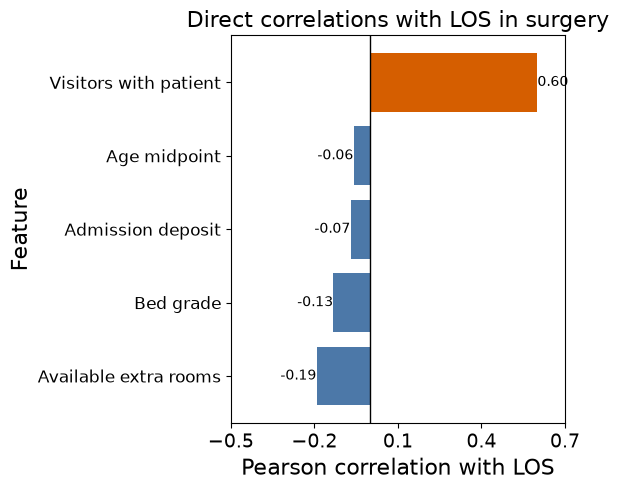

In [43]:
def show_direct_correlation_chart(direct_correlations: list[dict[str, Any]]) -> None:
    """Draw a bar chart of direct correlations with LOS for the longest-stay department."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    plot_rows = sorted(direct_correlations, key=lambda row: row["correlation"] or 0)
    labels = [row["label"] for row in plot_rows]
    values = [row["correlation"] or 0 for row in plot_rows]
    colors = ["#d55e00" if value > 0 else "#4c78a8" for value in values]

    _, axis = plt.subplots(figsize=(6, 5))
    axis.barh(labels, values, color=colors)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(f"Direct correlations with LOS in {longest_los_department}", fontsize=16)
    axis.set_xlabel("Pearson correlation with LOS", fontsize=16)
    axis.set_ylabel("Feature", fontsize=16)
    axis.tick_params(axis="x", labelsize=14)
    axis.tick_params(axis="y", labelsize=12)
    axis.set_xticks(np.arange(-0.5,1,0.3))

    for i, (label,value) in enumerate(zip(labels, values)):
        text_position = value + 0.001 if value >= 0 else value - 0.001
        alignment = "left" if value >= 0 else "right"
        axis.text(text_position, i , f"{value:.2f}", va="center", ha=alignment)

    plt.tight_layout()
    plt.show()

show_direct_correlation_chart(direct_correlations)

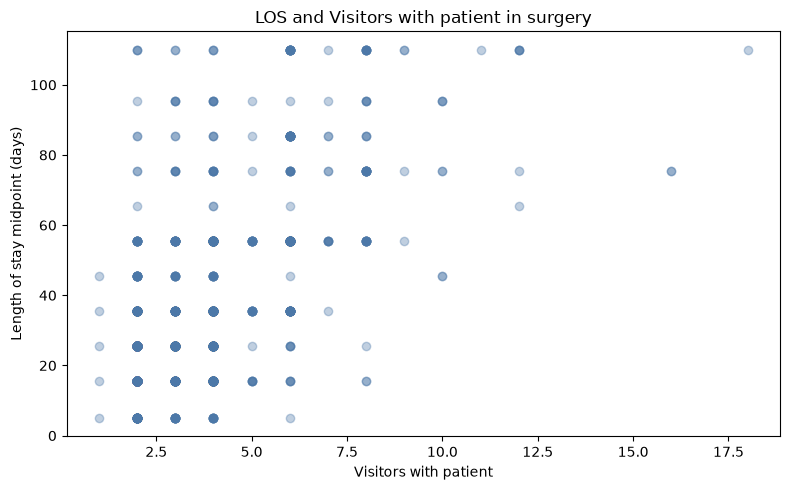

In [44]:
def show_strongest_direct_scatter(rows: list[dict[str, Any]], direct_correlations: list[dict[str, Any]]) -> None:
    """Draw a scatterplot for the feature with the strongest direct LOS correlation."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    strongest_feature = direct_correlations[0]["feature"]
    strongest_label = direct_correlations[0]["label"]
    department_rows = [row for row in rows if row["Department"] == longest_los_department]

    x_values = [row[strongest_feature] for row in department_rows if row[strongest_feature] is not None]
    y_values = [row["stay_days"] for row in department_rows if row[strongest_feature] is not None]

    _, axis = plt.subplots(figsize=(8, 5))
    axis.scatter(x_values, y_values, alpha=0.35, color="#4c78a8")
    axis.set_title(f"LOS and {strongest_label} in {longest_los_department}")
    axis.set_xlabel(strongest_label)
    axis.set_ylabel("Length of stay midpoint (days)")

    plt.tight_layout()
    plt.show()

show_strongest_direct_scatter(rows, direct_correlations)

##### **5. Second-order correlations inside the longest-stay department**

Second-order correlations check combinations of two variables. The interaction value is calculated by multiplying the two variables, then correlating that product with LOS.

In [45]:
def get_second_order_correlations(rows: list[dict[str, Any]], department: str) -> list[dict[str, Any]]:
    """Calculate how pairs of features together are related to LOS inside one department."""
    department_rows = [row for row in rows if row["Department"] == department]
    stay_values = [row["stay_days"] for row in department_rows]

    results = []
    for first_feature, second_feature in itertools.combinations(correlation_features, 2):
        interaction_values = []
        for row in department_rows:
            first_value = row[first_feature]
            second_value = row[second_feature]
            if first_value is None or second_value is None:
                interaction_values.append(None)
            else:
                # The interaction is the product of two features, for example visitors * deposit.
                interaction_values.append(first_value * second_value)

        correlation = pearson_correlation(interaction_values, stay_values)
        results.append(
            {
                "interaction": f"{feature_labels[first_feature]} x {feature_labels[second_feature]}",
                "correlation": correlation,
            }
        )

    return sorted(results, key=lambda row: abs(row["correlation"] or 0), reverse=True)

second_order_correlations = get_second_order_correlations(rows, longest_los_department)

for row in second_order_correlations:
    print(f"{row['interaction']:65} correlation={row['correlation']:6.3f}")

Visitors with patient x Admission deposit                         correlation= 0.514
Age midpoint x Visitors with patient                              correlation= 0.387
Visitors with patient x Bed grade                                 correlation= 0.374
Available extra rooms x Visitors with patient                     correlation= 0.326
Available extra rooms x Bed grade                                 correlation=-0.214
Available extra rooms x Admission deposit                         correlation=-0.179
Age midpoint x Available extra rooms                              correlation=-0.145
Admission deposit x Bed grade                                     correlation=-0.140
Age midpoint x Bed grade                                          correlation=-0.120
Age midpoint x Admission deposit                                  correlation=-0.091


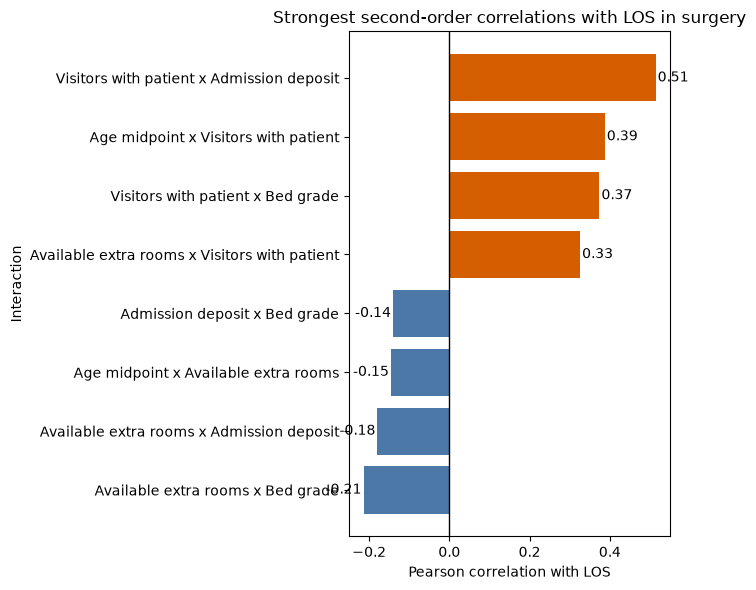

In [46]:
def show_second_order_correlation_chart(second_order_correlations: list[dict[str, Any]], limit: int = 8) -> None:
    """Draw a bar chart of the strongest feature-pair correlations with LOS."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    plot_rows = sorted(second_order_correlations[:limit], key=lambda row: row["correlation"] or 0)
    labels = [row["interaction"] for row in plot_rows]
    values = [row["correlation"] or 0 for row in plot_rows]
    colors = ["#d55e00" if value > 0 else "#4c78a8" for value in values]

    _, axis = plt.subplots(figsize=(7, 6))
    axis.barh(labels, values, color=colors)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(f"Strongest second-order correlations with LOS in {longest_los_department}")
    axis.set_xlabel("Pearson correlation with LOS")
    axis.set_ylabel("Interaction")

    for i, (label,value) in enumerate(zip(labels, values)):
        text_position = value + 0.005 if value >= 0 else value - 0.005
        alignment = "left" if value >= 0 else "right"
        axis.text(text_position, i , f"{value:.2f}", va="center", ha=alignment)

    plt.tight_layout()
    plt.show()

show_second_order_correlation_chart(second_order_correlations)

##### **6. Stay distribution by department**

The average LOS chart gives the main answer. This heatmap shows how patients are distributed across the original stay categories, which makes the department differences easier to see.

In [47]:
def get_department_stay_shares(rows: list[dict[str, Any]], department_los: list[dict[str, Any]]) -> list[dict[str, Any]]:
    """Calculate what percent of each department's patients falls into each Stay category."""
    departments = [row["department"] for row in department_los]
    share_rows = []

    for department in departments:
        department_rows = [row for row in rows if row["Department"] == department]
        total_patients = len(department_rows)
        shares = []

        for stay_category in stay_order:
            count = sum(1 for row in department_rows if row["Stay"] == stay_category)
            shares.append(count / total_patients * 100)

        share_rows.append({"department": department, "shares": shares})

    return share_rows

department_stay_shares = get_department_stay_shares(rows, department_los)
print(department_stay_shares[0])

{'department': 'surgery', 'shares': [5.599300087489064, 21.95975503062117, 21.95975503062117, 17.060367454068242, 3.5870516185476813, 16.62292213473316, 0.4374453193350831, 4.111986001749781, 3.062117235345582, 1.7497812773403325, 3.849518810148731]}


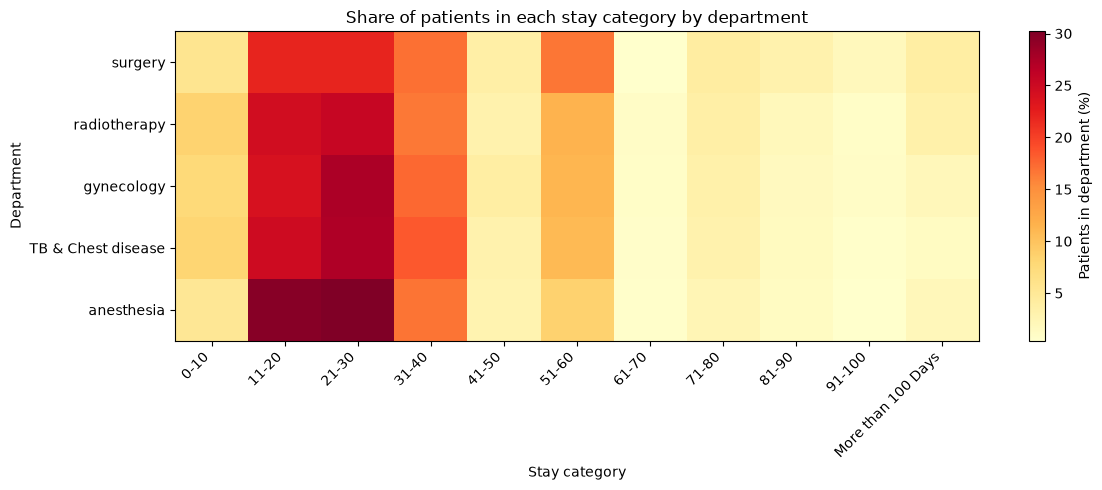

In [48]:
def show_stay_distribution_heatmap(department_stay_shares: list[dict[str, Any]]) -> None:
    """Draw a heatmap that shows how LOS categories are distributed inside each department."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("This visualisation needs matplotlib. Please run it in a notebook environment with matplotlib installed.")
        return

    departments = [row["department"] for row in department_stay_shares]
    matrix = [row["shares"] for row in department_stay_shares]

    figure, axis = plt.subplots(figsize=(12, 5))
    image = axis.imshow(matrix, cmap="YlOrRd", aspect="auto")

    axis.set_title("Share of patients in each stay category by department")
    axis.set_xlabel("Stay category")
    axis.set_ylabel("Department")
    axis.set_xticks(range(len(stay_order)))
    axis.set_xticklabels(stay_order, rotation=45, ha="right")
    axis.set_yticks(range(len(departments)))
    axis.set_yticklabels(departments)

    colorbar = figure.colorbar(image, ax=axis)
    colorbar.set_label("Patients in department (%)")

    plt.tight_layout()
    plt.show()

show_stay_distribution_heatmap(department_stay_shares)

#### **(iii) Conclusion**

##### **1. Function to print final results**

This final function prints the exact answer from the current CSV so it can be reused in the presentation or saved otherwise.

In [18]:
def print_final_interpretation(
    department_los: list[dict[str, Any]],
    direct_correlations: list[dict[str, Any]],
    second_order_correlations: list[dict[str, Any]],
) -> None:
    """Print the main results as short sentences that can be used in the presentation."""
    top_department = department_los[0]
    best_direct = direct_correlations[0]
    best_interaction = second_order_correlations[0]

    print("Main finding")
    print(
        f"- {top_department['department']} has the longest average length of stay "
        f"with {top_department['mean_stay_days']:.1f} days."
    )
    print()
    print("Direct correlation")
    print(
        f"- Inside {top_department['department']}, the strongest direct correlation with LOS is "
        f"{best_direct['label']} ({best_direct['correlation']:.2f})."
    )
    print()
    print("Second-order correlation")
    print(
        f"- The strongest second-order correlation is {best_interaction['interaction']} "
        f"({best_interaction['correlation']:.2f})."
    )
    print()
    print("Careful interpretation")
    print("- Correlation does not prove causation, but it helps identify which factors are most connected to long stays.")

print_final_interpretation(department_los, direct_correlations, second_order_correlations)

Main finding
- surgery has the longest average length of stay with 38.1 days.

Direct correlation
- Inside surgery, the strongest direct correlation with LOS is Visitors with patient (0.60).

Second-order correlation
- The strongest second-order correlation is Visitors with patient x Admission deposit (0.51).

Careful interpretation
- Correlation does not prove causation, but it helps identify which factors are most connected to long stays.


##### **2. Managerial findings and summary**


1. Surgery exhibits the longest average LOS (38.1 days, median 35.5). It should thus be the prime candidate for targeted efficiency investment.<br>Nevertheless, two things need to be considered:<br>
    (1) Surgery is overall the department with the least cases across data (1,143 patients against e.g. 245,850 in gynecology). While it struggles most per patient, the absolute financial burden remains limited. A hospital should therefore prioritize surgery for optimizations per case; but a majority of costs (volume) accumulate elsewhere.<br>
    (2) Within the surgical departments, the number of visitors with the patient shows by far the strongest correlation with LOS (r = 0.60.<br> Strongest interaction between "visitors" and "admission deposit": r = 0.51). Other factors (age, bed grade, additional room availability, ...) are only weakly related.

2. Visitor count is indicating case severity and required care intensity. It is observable early in the stay and without further analysis, therefore it can serve as a simple early-warning indicator for cases which risk exceeding the DRG time window ("obere Grenzverweildauer"). This could be usefully implemented within the surgical department.<br>

3. **Recommended actions: increase direct investment into the surgical department and use a high visitor count during the stay as a possible indication for exceeding the allocated time window.**


### **(3) LOS prediciton via Machine Learning (ML) Prediction Model**

#### **(i) Abstract and managerial motivation**



Under the above-mentioned G-DRG system, a hospital's margin depends mostly on whether the case's stay finishes within its predetermined (and fully financed) time window. Properly estimating a (new) patient's length of stay at admission via a predictive model enables:<br> 
1. **Bed and capacity management:** Forecasting occupancy weeks ahead and reducing costly overbooking or idle capacity <br><br>
2. **Early treatment planning:** Patients predicted to stay long can be dealt with via intensive care, raising the chance of finishing within the DRG window. <br><br>
3. **Staffing and material resource allocation:** Personnel as well as necessary material can be routed to the estimated workload. <br><br>
4. **Financial forecasting:** expected losses from enlengthened (:= over DRG limit) stays become more predictable at admission. A model adds value here due to the relevant managerial decisions only require distinguishing short stays from long stays. We hence trained a model that predicts the LOS category of a new patient based upon features available at admission time. <br><br>

#### **(ii) Model architecture and overview**

To transform the raw data frame into usable train and test tensors, we created a class that handles this transformation. It contains a function that first splits rows into a training and test part and then normalizes and one-hot codes the given feature columns. After creating the label column by extracting the "stay" column, we transformed the data frame into tensors (X_train, X_test, y_train, y_test). For the prediction part, we created a neural network which is able to classify input data into the given stay groups. The model consists of one input layer with 130 input neurons, 1 hidden layer with 512 neurons each, and an output layer with 11 neurons that represent the 11 stay groups. After the input neuron and each hidden neuron, we applied the ReLU activation function. As an optimizer we chose standard Adam, and as the loss we decided to use CrossEntropyLoss.

![Model architecture](./graphics/modelarchitecture1.png)

For the training loop we tracked the best test loss over the training process and stopped the training the moment when no better test loss was achieved. We decided to use the test loss for the model performance evaluation because by tracking the performance of the model based on the already seen data (training data) we would have the risk of taking a overfitted model as the best one. After the training loop ended, we loaded the parameters that were saved in the best run of the model and then save this model in an external file. This allows us to use this pre-trained model to make predictions on our dataset without the need to train again.

![](./graphics/consti.jpg)

To check the real accuracy of our model and to see how the model performs on the different length-of-stay groups, we split our data into 11 different datasets where each consists only of rows that have the length of stay x. Then we made predictions on each class and tracked the prediction of the model (you can see the result below). For example, the model predicts stay 0-10 in 21.8% of all cases as stay 0-10 (which is correct) but also predicts the stay group 0-10 in 43.1% of all cases as 11-20. Some classes, such as 41-50, are predicted with 0% accuracy because there were only a few rows of training data available for that class. During training, the model optimized for overall loss across all samples, so when the class is underrepresented, the model learns that it's statistically safer to predict a majority class instead of risking a wrong guess on a rare one. For example, since 21-30 has by far the most training examples, the model learns a high prior probability for it and tends to default to predicting 21-30 even for inputs that actually belong to a minority class like 41-50. As a result, the model essentially "gives up" on the rare classes in favor of minimizing loss on the classes it sees most often.

![Model architecture](./graphics/confusion_matrix_final.jpg)

#### **(iii) Training and implementing the model**

In [3]:
def set_seed(seed: int): #for reproduciblity
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)      # for GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
class Model(nn.Module):
    def __init__(self, in_features: int, hidden_units: int, out_features):
        super().__init__()
        #create a sequential Model layout
        self.Layer_stack = nn.Sequential(
            nn.Linear(in_features=in_features, out_features=hidden_units),
            nn.ReLU(), #activation function

            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),

            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),

            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),

            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),

            nn.Linear(in_features=hidden_units, out_features=out_features),
        )

    def forward(self, X):
        return self.Layer_stack(X) #takes data and fits it trough the layers

In [6]:
class Preprocessor:
    def __init__(self):
        self.categories = {} #holds a list of unique elements per column example: {'A': [1,2,...], 'B':["x", "y",...], ...}
        self.label_mapping = {} #holds the label groups mapped to their int mapping example: {'0-10': 0, '11-20': 1, ...}
        self.feature_columns = [] #saves list with all feature columns names (helps to allign the data in preiction) example: ['Ward_Type_P', 'Ward_Type_Q', 'Ward_Type_R'...]

        self.HOT_CODE_COLUMNS = [
            "Hospital_code", "Hospital_type_code", "City_Code_Hospital",
            "Hospital_region_code", "Department", "Ward_Type",
            "Ward_Facility_Code", "Type of Admission", "City_Code_Patient",
            "Age", "Bed Grade", "Severity of Illness"
        ]
        self.NORMALIZE_COLUMNS = [
            "Admission_Deposit", "Visitors with Patient",
            "Available Extra Rooms in Hospital",  # only the truly numeric ones
        ]
        self.LABEL_COLUMN = "Stay"
        self.DROP_COLUMNS = ["case_id", "patientid"]

        self.means = {} #holds mean of each NORMALIZE_COLUMS ecample: {'Admission_Deposit': np.float64(4.), 'Visitors with Patient': np.float64(3.), ...}
        self.stds = {} #holds list of standard deviations per NORMALIZE COLUMNS structure same as means

    def save(self, path="preprocessor.pt"):
        '''
        saves the stats of the Preprocessor.
        - categories (list of unique entries per column)
        - means (mean for each NORMALIZE COLUMN (only over training data))
        - stds (standard deviation for each NORMALIZE_COLUMNS (only over training data))
        - label_mapping (list each stay group mapped to an int)
        - feature_columns (list of names of all features for the model
        '''
        torch.save({
            "categories": self.categories,
            "means": self.means,
            "stds": self.stds,
            "label_mapping": self.label_mapping,
            "feature_columns": self.feature_columns,
        }, path)

    def load(self, path="preprocessor.pt"):
        '''loads the saved Preprocessor stats from training'''
        state = torch.load(path, weights_only=False)
        self.categories = state["categories"]
        self.means = state["means"]
        self.stds = state["stds"]
        self.label_mapping = state["label_mapping"]
        self.feature_columns = state["feature_columns"]

    def create_hot_code_mapping(self, data: pd.DataFrame):
        '''it fills self.categories with a list of unique entries per column'''
        for column in self.HOT_CODE_COLUMNS:
            self.categories[column] = sorted(data[column].dropna().unique().tolist())

    def apply_mapping(self, data: pd.DataFrame)->pd.DataFrame:
        '''takes a DataFrame and for each column in HOT_CODE_COLUMNS it splits it into new columns, 1 column per unique entries. Also it normalizes the columns of the original DataFrame that are stated in NORMALIZE_COLUMNS. It returns a new data Frame with structure: [Normalize_columns | hot coded columns]'''
        new_columns = {}
        for value in self.categories.items(): #{'A': [1,2,...], ...} takes the item ('A', [])
            for unique_value in value[1]: # takes the value []
                column_name = f"{value[0]}_{unique_value}" #creates a name for the new column
                new_columns[column_name] = (data[value[0]] == unique_value).astype(int) #row that = unique value -> 1 rest = 0

        hot = pd.DataFrame(new_columns, index=data.index)  #creates new DataFrame with the code coded columns in it

        # carry over the numeric columns that aren't hot-coded (from original DataFrame
        passthrough = data[self.NORMALIZE_COLUMNS].copy()

        full = pd.concat([passthrough, hot], axis=1) #merge DataFrames
        if self.means:  # only normalize once stats are learned
            full = self.normalize_data(full) #normalize the columns that come from the original DataFrame
        return full

    def map_label_columns_to_int(self, data:pd.DataFrame):
        '''takes the label column and maps each unique label to an int'''
        mapping = {}
        unique_data_points = sorted(data[self.LABEL_COLUMN].unique())  # get the unique data points per column in order
        mapping_values = [i for i in range(len(unique_data_points))]  # create a number (int) for each unique datapoint

        for data_point, mapping_value in zip(unique_data_points, mapping_values):  # iterates through both lists at the same time
            mapping[data_point] = mapping_value  # map a int value to the group and append in dict

        self.label_mapping = mapping #saves the mapping
        return mapping

    def normalize_data(self, data:pd.DataFrame)->pd.DataFrame:
        '''normalizes columns in NORMALIZE_COLUMNS'''
        data = data.copy()
        for column in self.NORMALIZE_COLUMNS:
            data[column] = (data[column] - self.means[column]) / self.stds[column] #every entry in every column (only NORMALIZE_COLUMNS
        return data

    def get_test_train_split(self, data: pd.DataFrame):
        '''splits the Data into train and test Data, hot-codes, normalize selected data and maps labels to an int. It returns 4 Tensors'''
        print("start loading train_test split...")

        # 1. split RAW data first (stats must come from raw train only)
        train_data, test_data = train_test_split(
            data, test_size=0.2, random_state=RANDOM_SEED, stratify=data[self.LABEL_COLUMN]
        )

        # 2. learn normalization stats from raw training rows
        for column in self.NORMALIZE_COLUMNS: #only NORMALIZE_COLUMNS
            self.means[column] = train_data[column].mean() #get mean for selected col (only with respect to training data) and save it
            self.stds[column] = train_data[column].std() #get Standard deviation selected col (only with respect to training data) and save it

        # 3. transform train and test — apply_mapping now normalizes (self.means is set), ONCE each
        X_train = self.apply_mapping(train_data)
        X_test = self.apply_mapping(test_data)
        self.feature_columns = X_train.columns.tolist()

        # 4. Transform labels labels for train and test
        mapping = self.map_label_columns_to_int(data)
        y_train = train_data[self.LABEL_COLUMN].map(mapping)
        y_test = test_data[self.LABEL_COLUMN].map(mapping)

        # 5. transform the data into tensors
        X_train = torch.tensor(X_train.values, dtype=torch.float32, device=DEVICE)
        X_test = torch.tensor(X_test.values, dtype=torch.float32, device=DEVICE)
        y_train = torch.tensor(y_train.values, dtype=torch.int64, device=DEVICE)
        y_test = torch.tensor(y_test.values, dtype=torch.int64, device=DEVICE)

        print("Done loading train_test_split")
        return X_train, X_test, y_train, y_test

    def predict_row(self, row_index, data, model, print_col=True):
        row = data.iloc[[row_index]] #extract the given row from the given DataFrame

        if print_col: #if needed print the values of each column of the row
            print(row)

        X = self.apply_mapping(row) #formats to usable input data for the model
        X = X.reindex(columns=self.feature_columns, fill_value=0) #bring the columns of the dataframe into the correct order (the order that is given by the training)
        X = torch.tensor(X.values, dtype=torch.float32, device=DEVICE) #transforms the formated data into a tensor

        with torch.inference_mode(): #turn of gradient tracking
            logits = model(X) #get the models raw output scores of the model
            idx = logits.argmax(dim=1).item() #select the output class with the highest score -> this is the prediction class

        inverse = {code: value for value, code in self.label_mapping.items()} #reverse keys and values of the label_mapping {"0-10": 0,...} -> {0: "0-10",...}
        pred = inverse[idx] #get the class coresponding to the index

        return pred


In [7]:
#accuracy function for the model
def accuracy_fn(y_pred, y_true):
    correct = torch.eq(y_true, y_pred).sum().item()  # compares how many y_true are equal to y_pred
    acc = (correct / len(y_pred)) * 100
    return acc

In [8]:
data = pd.read_csv(FILE_PATH) #load csv data
pre = Preprocessor()

In [9]:
#training and saving a model for prediction
set_seed(RANDOM_SEED)

if not os.path.exists("model_final.pt"): #only train if not pre-trained model exists
    pre.create_hot_code_mapping(data)
    X_train, X_test, y_train, y_test = pre.get_test_train_split(data) #split data and transform them into tensors
    out_features = len(pre.label_mapping)
    model = Model(in_features=len(pre.feature_columns), hidden_units=512, out_features=out_features).to(DEVICE) #create a Model

    #choose optimizer and loss function
    optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    # training loop
    epoch = 0
    break_counter = 0 #tracks how often in a row the new test_loss is not smaller then the previouse best loss
    best_loss = float("inf")
    while True:
        epoch += 1
        # get a random Batch
        permutation = torch.randperm(len(X_train))  # get random index list for random batches
        train_loss, train_acc = 0, 0 #reset train_loss and train_accuracy for new epoch
        batch_count = 0 #track in which batch we are in

        model.train()
        for start in range(0, len(X_train), TRAINING_BATCH_SIZE):
            batch_count += 1
            indexes = permutation[start:start + TRAINING_BATCH_SIZE] #get indexes from premutation (it basacilly shuffles the data
            X_batch, y_batch = X_train[indexes], y_train[indexes] #get a Batch

            y_preds = model(X_batch) #intput batch into model and get back the class scores
            loss = loss_fn(y_preds, y_batch) #calculate the loss for this batch
            acc = accuracy_fn(y_preds.argmax(dim=1), y_batch) #accuracy score of this batch

            #add loss and accuracy for the oss and acc over the entire data set
            train_loss += loss.item()
            train_acc += acc

            optimizer.zero_grad() #set gradient to zero such that it doesn't accumulate over time
            loss.backward() #calculate the gradient for this loss (what impact does each parameter has on the loss function)
            optimizer.step() #adjust the parameters of the model based on the calculated gradient

        train_loss /= batch_count #get overall loss of the model over the entire data set
        train_acc /= batch_count #get overall accuracy of the model over the entire data set

        with torch.inference_mode(): #turn of gradient tracking for evaluation of the model
            test_loss, test_acc = 0, 0
            batch_count = 0

            model.eval()
            #no "shuffling" needed for evaluation
            for start in range(0, len(X_test), TEST_BATCH_SIZE):
                #get a batch
                X_batch_test = X_test[start:start + TEST_BATCH_SIZE]
                y_batch_test = y_test[start:start + TEST_BATCH_SIZE]

                batch_count += 1

                y_preds_test = model(X_batch_test) #get prediction of the model on the batch
                loss = loss_fn(y_preds_test, y_batch_test) #calculate loss of the batch
                acc = accuracy_fn(y_preds_test.argmax(dim=1), y_batch_test) #calculate accuracy of the batch

                #add loss and acc
                test_loss += loss.item()
                test_acc += acc

            #calculate loss and accuracy of the model over the entire Data set
            test_loss /= batch_count
            test_acc /= batch_count

            print(f"{epoch} | train_loss: {train_loss:.5f}, test_loss: {test_loss:.5f}, train_acc: {train_acc:.3f} test_acc: {test_acc:.3f} counter: {break_counter}")

            if test_loss <= best_loss: #check if the current test_loss is better (lower) then the current best loss saved
                best_loss = test_loss #if the loss is lower, then save it as the new best loss
                break_counter = 0
                torch.save(model.state_dict(), "checkpoint.pth") #save the best current model parameters

            else: #if the current test_loss is not lower then the current best loss -> increase the counter
                break_counter += 1

            #if the model didn't achieve a better test loss (lower) then the best loss in 10 epochs, then end training
            if break_counter >= 10:
                break

    pre.save() #save the states

    #rebuild the best model, and load best weights
    export_model = Model(
        in_features=len(pre.feature_columns),
        hidden_units=512,
        out_features=out_features,
    )

    export_model.load_state_dict(torch.load("checkpoint.pth", weights_only=True)) #load the parameters of the lowest test_loss epoch into the model
    export_model.eval()
    torch.jit.script(export_model).save("model_final.pt")   #save the model as a self_contained model
    print("saved preprocessor.pt + model_final.pt")

else:
    print("found pre-trained model: model_final.pt — skipping training")


found pre-trained model: model_final.pt — skipping training


In [10]:
# load preprocessor and evaluation model
pre = Preprocessor()
pre.load("preprocessor.pt")
model = torch.jit.load("model_final.pt", map_location=DEVICE) #load the model for evaluation
model.eval() #sets model into evaluation mode

# get the SAME test split (seed is fixed, so reproducible)
set_seed(RANDOM_SEED)
_, X_test, _, y_test = pre.get_test_train_split(data)

with torch.inference_mode():
    logits = model(X_test) #get class output scores
    total_acc = accuracy_fn(logits.argmax(dim=1), y_test) #calculate the accuracy over the entire test data set

print(f"Test accuracy: {total_acc:.2f}%")

start loading train_test split...
Done loading train_test_split
Test accuracy: 42.32%


In [13]:
# predict on set amount of random rows (num_test_rows) and compare to the true Stay
num_test_rows = 30 # set the amount of rows to test model on
random_indices = random.sample(range(len(data)), num_test_rows)  #  num_test_rows distinct row positions (change variable above if necessary)

correct = 0
for row_index in random_indices: #interates through the random_indices list
    pred = pre.predict_row(row_index, data=data, model=model, print_col=False) #get the prediction of the model on this row
    true_val = data.iloc[row_index][pre.LABEL_COLUMN] #extract the true Stay from the DataFrame
    print(f"pred: {pred} | true: {true_val}")
    if pred == true_val:
        correct += 1

print(f"\n{correct}/{num_test_rows} correct")
correct_percentage = round(correct / num_test_rows * 100, 2)
print(f"(This equals roughly {correct_percentage}% accuracy)")
#also includes rows from training it is just as a demo

pred: 11-20 | true: 11-20
pred: 21-30 | true: 41-50
pred: 11-20 | true: 21-30
pred: 51-60 | true: 51-60
pred: 51-60 | true: 81-90
pred: 21-30 | true: 31-40
pred: 21-30 | true: 31-40
pred: 31-40 | true: 21-30
pred: 21-30 | true: 21-30
pred: 31-40 | true: 31-40
pred: 11-20 | true: 0-10
pred: 21-30 | true: 21-30
pred: 11-20 | true: 11-20
pred: 51-60 | true: 31-40
pred: 21-30 | true: 21-30
pred: 21-30 | true: 51-60
pred: 21-30 | true: 31-40
pred: 21-30 | true: 21-30
pred: 21-30 | true: 21-30
pred: 0-10 | true: 71-80
pred: 21-30 | true: 21-30
pred: 11-20 | true: 11-20
pred: 11-20 | true: 0-10
pred: 21-30 | true: 31-40
pred: 21-30 | true: 21-30
pred: 51-60 | true: 51-60
pred: 51-60 | true: 31-40
pred: 21-30 | true: 31-40
pred: 51-60 | true: 51-60
pred: 0-10 | true: 0-10

15/30 correct
(This equals roughly 50.0% accuracy)


#### **(iv) Problems of the model**



Some classes (e.g. [41-50]) are predicted with 0% accuracy, since only few rows of training data are available for that class. During the training, the model optimized for overall loss across all samples. <br>
-> For the underrepresented class, the model learns that it is statistically safer to predict a majority class instead of risking a wrong guess on a rare one!<br> E.g.: [21-30] has by far the most training examples. The model learns a high prior probability, and thus tends to default to predicting [21-30]. Even for inputs that belong to a minority class, e.g. [41-50]. <br>
-> Result: model essentially "gives up“ on the rare classes in favor of minimizing loss on the common classes!

#### **(v) Conclusion**

The Model can still be used as rough estimate/predictor, since most errors fall into adjacent categories! <br>
Also, the model could be refined through collection and usage of more training data. <br>
The Infrastructure of of our model is suitable for this! <br>


### **(4) Final summary**

In this project, we analyzed 313,793 cleaned hospital records to help with the two aspects mentioned in the beginning.
1. Surgery is the department with the longest average LOS (38.1 days, median 35.5), ahead of e.g. radiotherapy (33.7) and gynecology (32.6).<br>Within surgery, visitor count correlates most strongly with LOS (r = 0.60), making it a cheap early-warning indicator for stays at risk of exceeding the DRG time window. Surgical department is thus the prime candidate for targeted efficiency investment, though high-volume gynecology (245,850 cases) carries the largest absolute exposure.
2. A self-trained machine learning model predicts a newly admitted patient's LOS category from admission-time features with 42.3% test accuracy across 11 classes (vs. ~9% random baseline), with most errors falling into adjacent categories. Thus, it is accurate enough to support bed capacity planning, early discharge management, and staffing decisions at admission.

### **(5) Contributions of team members**

- Muhammad Sheheryaar Ghayas (03801683): Creation of UML diagrams, explorative analysis of data, creation of further visualisations
- Vsevolods Mitrevics (03815799): Creating functions for data loading, cleaning, aggregating and visualizing (for Task I).
- Constantin Demuth (03818527): Creating, training, testing and documenting ML model (for Task II).
- Stanislaw Pohl (03822985): Data analysis and exploration regarding suitable management questions, visualisations, research on healthcare system and contextual information
- Jannis Nickel (03813516): Report, Presentation, Explorative Data analysis, Github Repo Management,
    Compilation of final notebook & deliverables





(Please note that we spent a considerable amount of effort on exploring the given data before making a decision on a managerial aspect we want to analyze for our project. Thus, contributions in the final deliverables may not look equally distributed.)